<a href="https://colab.research.google.com/github/pavlinxic/clip/blob/main/EDA%20%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D1%8D%D0%BB%D0%B5%D0%BA%D1%82%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9%20%D0%BA%D0%BE%D0%BC%D0%B5%D1%80%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [5]:
sns.set_style('whitegrid')
plt.rcParams["figure.figsize"] = (10, 6)

In [10]:
df = pd.read_csv("/content/consumer_shopping_behavior_survey.csv")

In [11]:
df.head()

,Response_ID,Timestamp,Age,Gender,Occupation_Status,Country_Region,Monthly_Income_Range,Shop_Most_Where,Online_Shopping_Frequency,Preferred_Platform,...,Return_Frequency,Avg_Monthly_Spend_NonEssentials,Preferred_Payment_Method,Uses_BNPL_Installments,Online_Shopping_Satisfaction_Score,Trust_In_Online_Reviews_Score,Regret_After_Purchase_Frequency,Reason_Prefer_Online,Reason_Prefer_InStore,Best_Shopping_Mode
0,1,01/08/2026 12:30:25,20,Male,NaN,Philippines,"Under $1,000",Equal mix,Often,Physical stores,...,Never,Under $50,Digital wallet,"Yes, occasionally",6.0,7.0,2.0,More variety,No delivery wait,Online
1,2,21/06/2026 13:52:02,24,Male,Employed part-time,Brazil,"Under $1,000",In-store only,Often,Local e-commerce,...,Often,Under $50,Digital wallet,"No, never",5.0,8.0,3.0,NaN,Try product before buying,Offline
2,3,15/08/2026 04:24:18,22,Female,Student,India,"Under $1,000",Equal mix,Always,Local e-commerce,...,Sometimes,$150-300,Credit Card,"No, never",7.0,6.0,2.0,Better prices,Trust,Online
3,4,23/06/2026 21:24:21,20,Male,Student,NaN,"Under $1,000",In-store only,Occasionally,Brand websites,...,Never,Under $50,Debit Card,"No, never",8.0,7.0,3.0,Better prices,Try product before buying,Equal / both
4,5,20/08/2026 16:24:47,41,Male,Employed full-time,United States,"$1,000-3,000",Equal mix,Occasionally,NaN,...,Sometimes,$50-150,Debit Card,"No, never",6.0,8.0,2.0,Convenience,Trust,Equal / both


In [12]:
df.columns

Index(['Response_ID', 'Timestamp', 'Age', 'Gender', 'Occupation_Status',
       'Country_Region', 'Monthly_Income_Range', 'Shop_Most_Where',
       'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device',
       'Top_Spending_Category', 'Review_Influence_Score',
       'Social_Ads_Influence_Score', 'Price_Comparison_Frequency',
       'Discount_Importance_Score', 'Follows_Brands_On_Social',
       'Likely_To_Buy_After_Ad_Score', 'Makes_Shopping_List',
       'Impulse_Purchase_Frequency', 'Return_Frequency',
       'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method',
       'Uses_BNPL_Installments', 'Online_Shopping_Satisfaction_Score',
       'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency',
       'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode'],
      dtype='object')

In [13]:
df.shape

(500, 30)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Response_ID                         500 non-null    int64  
 1   Timestamp                           500 non-null    object 
 2   Age                                 478 non-null    object 
 3   Gender                              484 non-null    object 
 4   Occupation_Status                   479 non-null    object 
 5   Country_Region                      480 non-null    object 
 6   Monthly_Income_Range                479 non-null    object 
 7   Shop_Most_Where                     484 non-null    object 
 8   Online_Shopping_Frequency           481 non-null    object 
 9   Preferred_Platform                  486 non-null    object 
 10  Primary_Device                      492 non-null    object 
 11  Top_Spending_Category               476 non-n

In [16]:
df.isna().sum()

,0
Response_ID,0
Timestamp,0
Age,22
Gender,16
Occupation_Status,21
Country_Region,20
Monthly_Income_Range,21
Shop_Most_Where,16
Online_Shopping_Frequency,19
Preferred_Platform,14


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format="%d/%m/%Y %H:%M:%S")


In [20]:
df[['Age', 'Timestamp']].dtypes

,0
Age,float64
Timestamp,datetime64[ns]


In [21]:
df['Age'].describe()

,Age
count,470.000000
mean,25.019149
std,7.515276
min,16.000000
25%,20.000000
50%,22.000000
75%,30.000000
max,50.000000


In [22]:
df['Reason_Prefer_Online'].value_counts()

,count
Reason_Prefer_Online,
More variety,170
Convenience,157
Better prices,81
Not applicable,38


In [23]:
bins = [0, 18, 25, 35, 50, 100]
labels = ['under 18', '18-25', '26-35', '36-50', '50+']
df['Age_Group'] = pd.cut(df['Age'], bins = bins, labels = labels)


In [24]:
df['Age_Group'].value_counts()

,count
Age_Group,
18-25,228
26-35,110
under 18,78
36-50,54
50+,0


In [25]:
cols_to_fill = ['Gender', 'Occupation_Status', 'Country_Region', 'Shop_Most_Where', 'Preferred_Platform', 'Preferred_Payment_Method']

In [26]:
for col in cols_to_fill:
  df[col] = df[col].fillna('Unknow')

In [27]:
df[cols_to_fill].isna().sum()

,0
Gender,0
Occupation_Status,0
Country_Region,0
Shop_Most_Where,0
Preferred_Platform,0
Preferred_Payment_Method,0


In [28]:
last6 = ['Online_Shopping_Satisfaction_Score',
       'Trust_In_Online_Reviews_Score', 'Regret_After_Purchase_Frequency',
       'Reason_Prefer_Online', 'Reason_Prefer_InStore', 'Best_Shopping_Mode']

In [29]:
dropoff = df[last6].isna().all(axis=1)

In [30]:
dropoff.sum()

np.int64(30)

In [31]:
df.loc[dropoff, 'Timestamp'].dt.date.value_counts().sort_index()

,count
Timestamp,
2026-06-20,1
2026-06-22,1
2026-06-24,1
2026-06-29,1
2026-06-30,1
2026-07-02,1
2026-07-03,1
2026-07-05,1
2026-07-06,1


In [33]:
pd.crosstab(df['Shop_Most_Where'], df['Reason_Prefer_InStore'], dropna=False)

Reason_Prefer_InStore,No delivery wait,Not applicable,Trust,Try product before buying,NaN
Shop_Most_Where,,,,,
Equal mix,54,42,49,74,29
In-store only,15,10,16,21,9
Online only,43,20,51,46,5
Unknow,7,0,3,4,2


In [59]:
age_summary = df.groupby('Age_Group', observed=True).agg(
    avg_satisfaction=('Online_Shopping_Satisfaction_Score', 'mean'),
    avg_trust=('Trust_In_Online_Reviews_Score', 'mean'),
    avg_reget=('Regret_After_Purchase_Frequency', 'mean'),
    respondents=('Response_ID', 'count')
).round(2)
age_summary

,avg_satisfaction,avg_trust,avg_reget,respondents
Age_Group,,,,
under 18,7.25,6.06,2.06,78
18-25,7.04,6.11,2.29,228
26-35,7.17,6.14,2.17,110
36-50,7.02,6.48,1.93,54


In [60]:
top_countries = df['Country_Region'].value_counts().head(8).index

In [61]:
top_countries

Index(['India', 'United States', 'Brazil', 'Mexico', 'Indonesia', 'Kenya',
       'Egypt', 'Philippines'],
      dtype='object', name='Country_Region')

In [63]:
country_summary = df[df['Country_Region'].isin(top_countries)].groupby('Country_Region').agg(
    avg_satisfaction = ('Online_Shopping_Satisfaction_Score', 'mean'),
    bnpl_regular_rate = ('Uses_BNPL_Installments', lambda x: (x == 'Yes, regulary').mean()),
    respondents = ('Response_ID', 'count')
)
country_summary

,avg_satisfaction,bnpl_regular_rate,respondents
Country_Region,,,
Brazil,7.114286,0.0,38
Egypt,6.521739,0.0,25
India,6.779661,0.0,66
Indonesia,7.434783,0.0,26
Kenya,7.240000,0.0,26
Mexico,7.250000,0.0,35
Philippines,7.090909,0.0,23
United States,7.387755,0.0,56


In [64]:
occupation_summary = df.groupby('Occupation_Status').agg(
    avg_impulse = ('Impulse_Purchase_Frequency', 'mean'),
    avg_discount_importance = ('Discount_Importance_Score', 'mean'),
    bnpl_regular_rate = ('Uses_BNPL_Installments', lambda x: (x == 'Yes, regulary').mean()),
    respondents = ('Response_ID', 'count')
).round(2).sort_values('avg_impulse', ascending=False)
occupation_summary


,avg_impulse,avg_discount_importance,bnpl_regular_rate,respondents
Occupation_Status,,,,
Employed part-time,2.86,3.94,0.0,71
Student,2.61,3.80,0.0,238
Unknow,2.50,3.67,0.0,21
Employed full-time,2.46,3.90,0.0,118
Self-employed,2.45,3.78,0.0,33
Unemployed,2.44,3.47,0.0,19


In [66]:
pivot_paymant = pd.pivot_table(
    df, index = 'Shop_Most_Where', columns='Preferred_Payment_Method',
    values= 'Response_ID', aggfunc='count', fill_value=0
)

In [67]:
pivot_payment_pct = pivot_paymant.div(pivot_paymant.sum(axis=1), axis=0).round(2)

In [68]:
pivot_payment_pct

Preferred_Payment_Method,Cash,Credit Card,Debit Card,Digital wallet,Unknow
Shop_Most_Where,,,,,
Equal mix,0.14,0.21,0.27,0.35,0.02
In-store only,0.14,0.25,0.23,0.34,0.04
Online only,0.11,0.22,0.24,0.39,0.03
Unknow,0.12,0.12,0.31,0.38,0.06


In [69]:
pivot_gender_spend = pd.pivot_table(
    df, index = 'Gender', columns='Top_Spending_Category',
    values = 'Response_ID', aggfunc='count', fill_value=0
)

In [70]:
pivot_gender_spend_pct = pivot_gender_spend.div(pivot_gender_spend.sum(axis=1), axis=0).round(2)

In [71]:
pivot_gender_spend_pct

Top_Spending_Category,Beauty & personal care,Books,Clothing,Electronics,Groceries,miscellaneous
Gender,,,,,,
Female,0.06,0.09,0.38,0.14,0.21,0.12
Male,0.08,0.07,0.40,0.16,0.18,0.10
Prefer not to say,0.10,0.10,0.22,0.24,0.18,0.14
Unknow,0.00,0.13,0.40,0.13,0.20,0.13


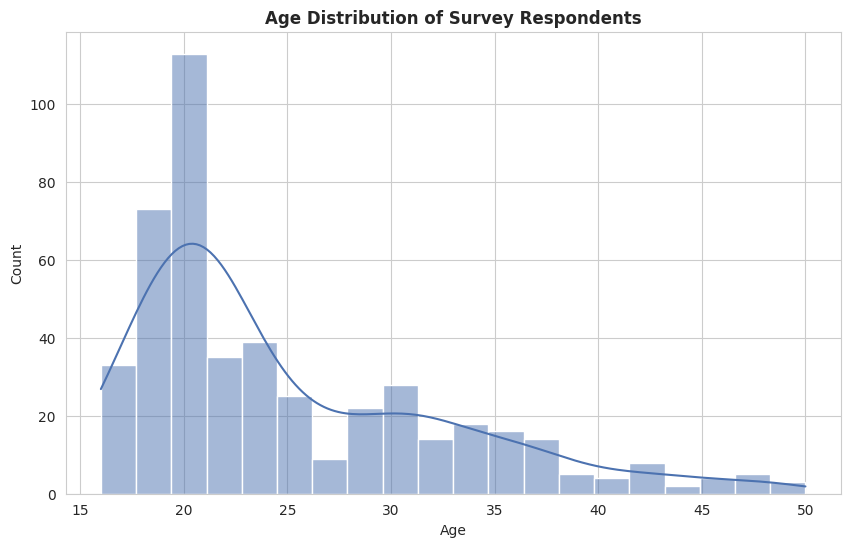

In [75]:
sns.histplot(df['Age'].dropna(), bins=20, kde=True, color='#4C72B0')
plt.title('Age Distribution of Survey Respondents', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


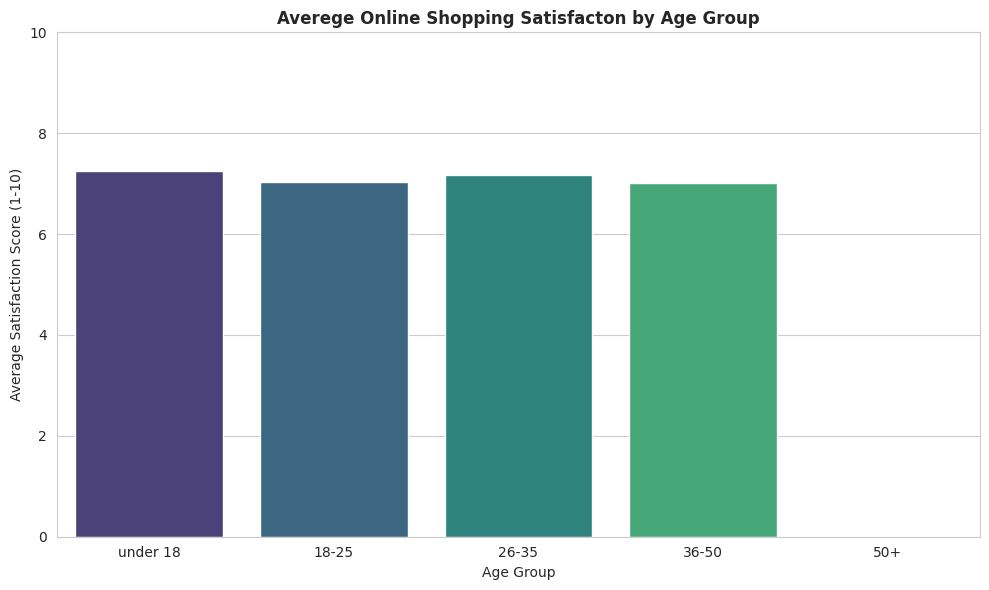

In [76]:
sns.barplot(x = age_summary.index, y = age_summary['avg_satisfaction'], palette='viridis')
plt.title('Averege Online Shopping Satisfacton by Age Group', fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Satisfaction Score (1-10)')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

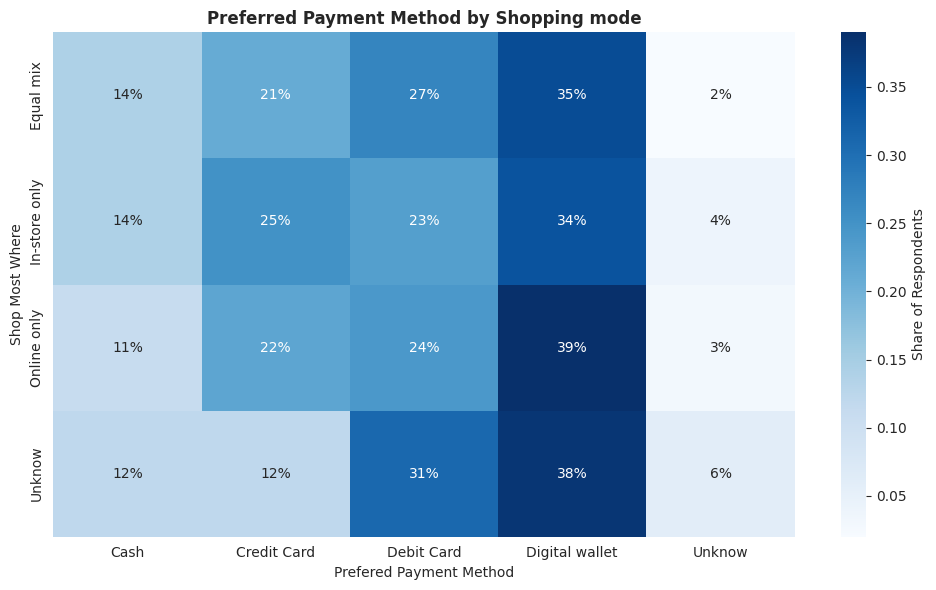

In [84]:
sns.heatmap(pivot_payment_pct, annot=True, cmap='Blues', fmt = '.0%', cbar_kws={'label':'Share of Respondents'})
plt.title('Preferred Payment Method by Shopping mode', fontweight='bold')
plt.xlabel('Prefered Payment Method')
plt.ylabel('Shop Most Where')
plt.tight_layout()
plt.show()

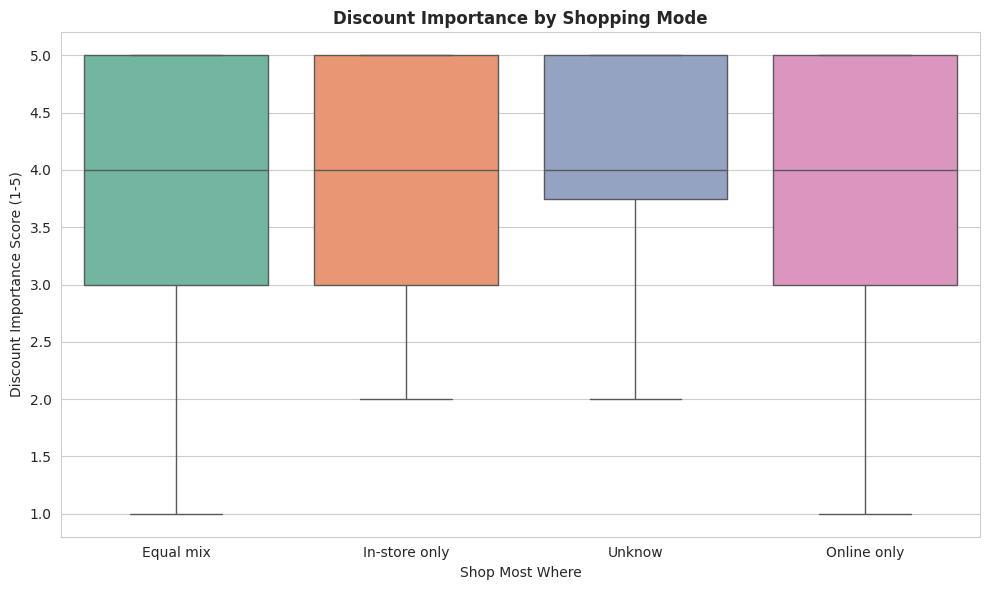

In [89]:
sns.boxplot(x = 'Shop_Most_Where', y= 'Discount_Importance_Score', data=df, palette='Set2')
plt.title('Discount Importance by Shopping Mode', fontweight = 'bold')
plt.xlabel('Shop Most Where')
plt.ylabel('Discount Importance Score (1-5)')
plt.tight_layout()
plt.show()